In [10]:
# notebook magics
# inline/notebook/interactive
%matplotlib notebook
%load_ext autoreload
%autoreload 2

import os
# os.chdir("./3D")
os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'/home/nb0817/ps-model-exact/2D'

In [68]:
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 150
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 100  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!

import fixed_center_of_mass_exact_3D as fcm

os.chdir("../2D")
import fixed_center_of_mass_exact_2D as fcm2D

In [78]:
base_params = {
        'g_1': 1.0, 'g_2': 1.0,
        'M_1': 300, 'M_2': 300,
        'NR': 12, 'Nr': 13, 'Ng': 14,
        'J': 0, 'potential': 'borgis',
        'preconditioner': 'naive',
        'verbosity': 0
    }
args = Namespace(**base_params)
H = fcm.Hamiltonian(args)

Waring: All masses scaled to AMU for borgis!
Potential: borgis
extent in unscaled coords: [4.129 5.355] 5.355
extent in   scaled coords: [14.4560121  18.74835185] 1.5295224470104511
[Build Vsph from Vgrid] Elapsed time: 1.17e+05us
Preconditioner requires 0MB.
[Build preconditioner naive] Elapsed time: 23.9us


In [79]:
Ad_vn, Ad_n = H.BO_spectrum()
print(Ad_n.shape)
print(Ad_vn.shape)

Building BO spectrum
memory constraint threshold = 100000.0, False
Mock call to tqdm({'total': 12})
(12, 182)
(12, 182)


<IPython.core.display.Javascript object>

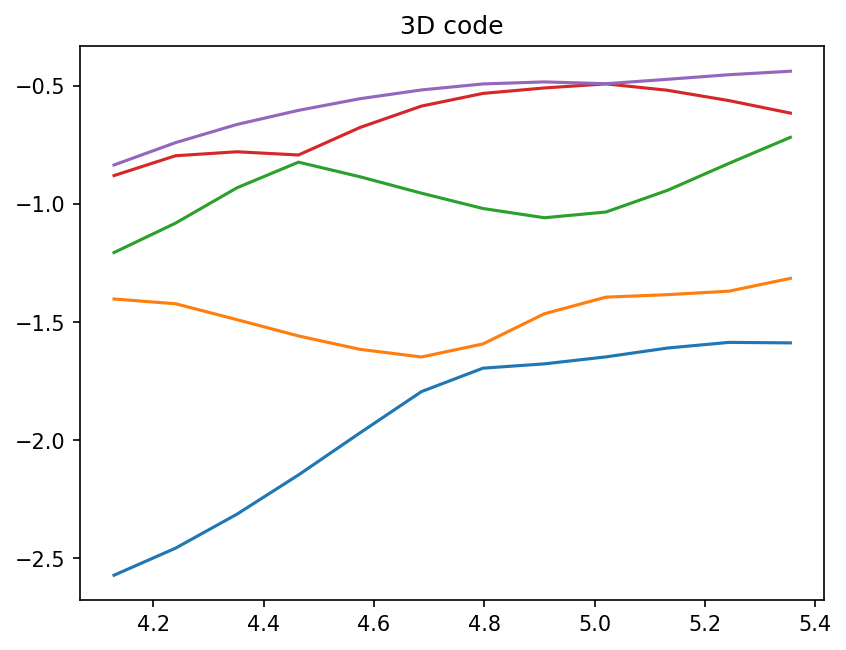

In [81]:
fig,ax = plt.subplots()
ax.plot(H.R_lab, Ad_n[:,0])
# ax.plot(H.R_lab, Ad_vn[:,0])
ax.plot(H.R_lab, Ad_n[:,1]) 
ax.plot(H.R_lab, Ad_n[:,2])
ax.plot(H.R_lab, Ad_n[:,3])
ax.plot(H.R_lab, Ad_n[:,4])

ax.set_title("3D code")
display(fig)

In [72]:
H2D = fcm2D.Hamiltonian(args)
Ad_vn, Ad_n = H2D.BO_spectrum()

Waring: All masses scaled to AMU for borgis!
Potential: borgis
extent in unscaled coords: [4.129 5.355] 5.355
extent in   scaled coords: [14.4560121  18.74835185] 1.5295224470104511
Preconditioner requires 0MB.
[Build preconditioner naive] Elapsed time: 21.5us
Building BO spectrum
memory constraint threshold = 100000.0, False
Mock call to tqdm({'total': 12})


<IPython.core.display.Javascript object>

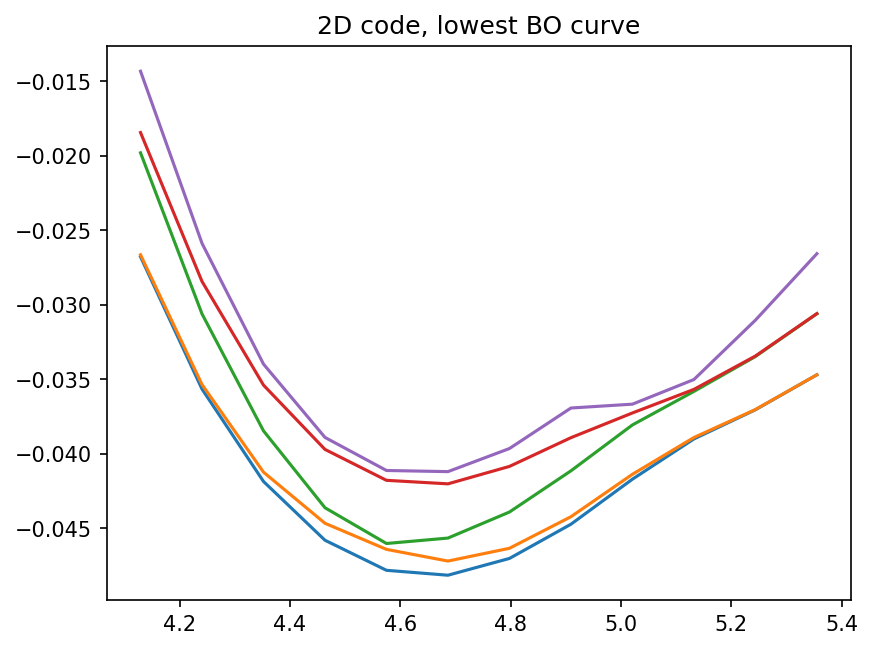

In [73]:
fig,ax = plt.subplots()
ax.plot(H.R_lab, Ad_n[:,0])
ax.plot(H.R_lab, Ad_n[:,1]) 
ax.plot(H.R_lab, Ad_n[:,2])
ax.plot(H.R_lab, Ad_n[:,3])
ax.plot(H.R_lab, Ad_n[:,4])
ax.set_title("2D code, lowest BO curve")
display(fig)